# cvmeasure walkthrough

From a synthetic sheep-loin ultrasound frame to the four measurements a scanning technician records
(eye muscle area / depth / width, fat depth C), with the trained U-Net.

Run from the repository root after `scripts/make_dataset.py` and training (see README).

In [1]:
import sys, json, numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
sys.path.insert(0, "../src")
from cvmeasure.synth.generator import SheepLoinUltrasoundGenerator, GeneratorConfig
from cvmeasure.measure.measurements import measure_from_label_map, MEASUREMENT_KEYS
from cvmeasure.viz import overlay
plt.rcParams["figure.dpi"] = 100

## 1. Simulate a frame
The generator samples an animal (anatomy) and a frame (acquisition nuisance factors) and renders a B-mode image with pixel-perfect labels.

In [2]:
gen = SheepLoinUltrasoundGenerator(GeneratorConfig(), seed=42)
animal = gen.sample_animal(); frame = gen.sample_frame_params()
s = gen.render(animal, frame)
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(s.image, cmap="gray"); ax[0].set_title("synthetic B-mode frame"); ax[0].axis("off")
overlay(ax[1], s.image / 255.0, s.mask, s.pixel_spacing_mm, "ground truth")
plt.show()
{k: round(v, 2) for k, v in s.measurements.items() if k in MEASUREMENT_KEYS}

{'ema_mm2': 1666.45, 'emd_mm': 33.18, 'emw_mm': 69.3, 'fat_c_mm': 7.14}

## 2. Run the trained U-Net and measure the predicted mask

In [3]:
from cvmeasure.evaluate import load_checkpoint
model, ck = load_checkpoint("../weights/unet_synthetic_v0.1.pt")
x = torch.from_numpy(s.image.astype(np.float32) / 255.0)[None, None]
with torch.no_grad():
    pred = model(x).argmax(1)[0].numpy()
m_pred = measure_from_label_map(pred, s.pixel_spacing_mm, clean=True)
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
overlay(ax[0], s.image / 255.0, s.mask, s.pixel_spacing_mm, "reference")
overlay(ax[1], s.image / 255.0, pred, s.pixel_spacing_mm, "U-Net prediction")
plt.show()
pd.DataFrame({"reference": {k: s.measurements[k] for k in MEASUREMENT_KEYS},
              "predicted": {k: m_pred[k] for k in MEASUREMENT_KEYS}}).round(2)

,reference,predicted
ema_mm2,1666.45,1674.21
emd_mm,33.18,33.18
emw_mm,69.30,69.72
fat_c_mm,7.14,7.39


## 3. Test-set agreement statistics
Produced by `python -m cvmeasure.evaluate` (in-distribution test split and the harder domain-shift set).

In [4]:
for name in ("test", "shift"):
    try:
        mtr = json.load(open(f"../reports/{name}/metrics.json"))
    except FileNotFoundError:
        print(name, "not evaluated yet"); continue
    print(f"== {name}: Dice muscle {mtr['segmentation']['dice_muscle']:.3f}, Dice fat {mtr['segmentation']['dice_fat']:.3f}")
    display(pd.DataFrame(mtr["seg_measurements"]).T[["mae", "rmse", "bias", "r2", "ccc", "loa_low", "loa_high"]].round(3))

== test: Dice muscle 0.994, Dice fat 0.961


,mae,rmse,bias,r2,ccc,loa_low,loa_high
ema_mm2,6.872,8.752,0.050,0.999,1.000,-17.137,17.237
emd_mm,0.134,0.242,0.067,0.998,0.999,-0.391,0.525
emw_mm,0.577,0.778,0.154,0.987,0.993,-1.342,1.651
fat_c_mm,0.406,0.689,0.327,0.853,0.922,-0.863,1.517


== shift: Dice muscle 0.992, Dice fat 0.959


,mae,rmse,bias,r2,ccc,loa_low,loa_high
ema_mm2,13.214,16.315,-9.990,0.998,0.999,-35.324,15.343
emd_mm,0.148,0.266,0.044,0.997,0.998,-0.473,0.560
emw_mm,0.687,0.869,-0.310,0.984,0.992,-1.905,1.284
fat_c_mm,0.430,0.685,0.340,0.877,0.937,-0.829,1.508


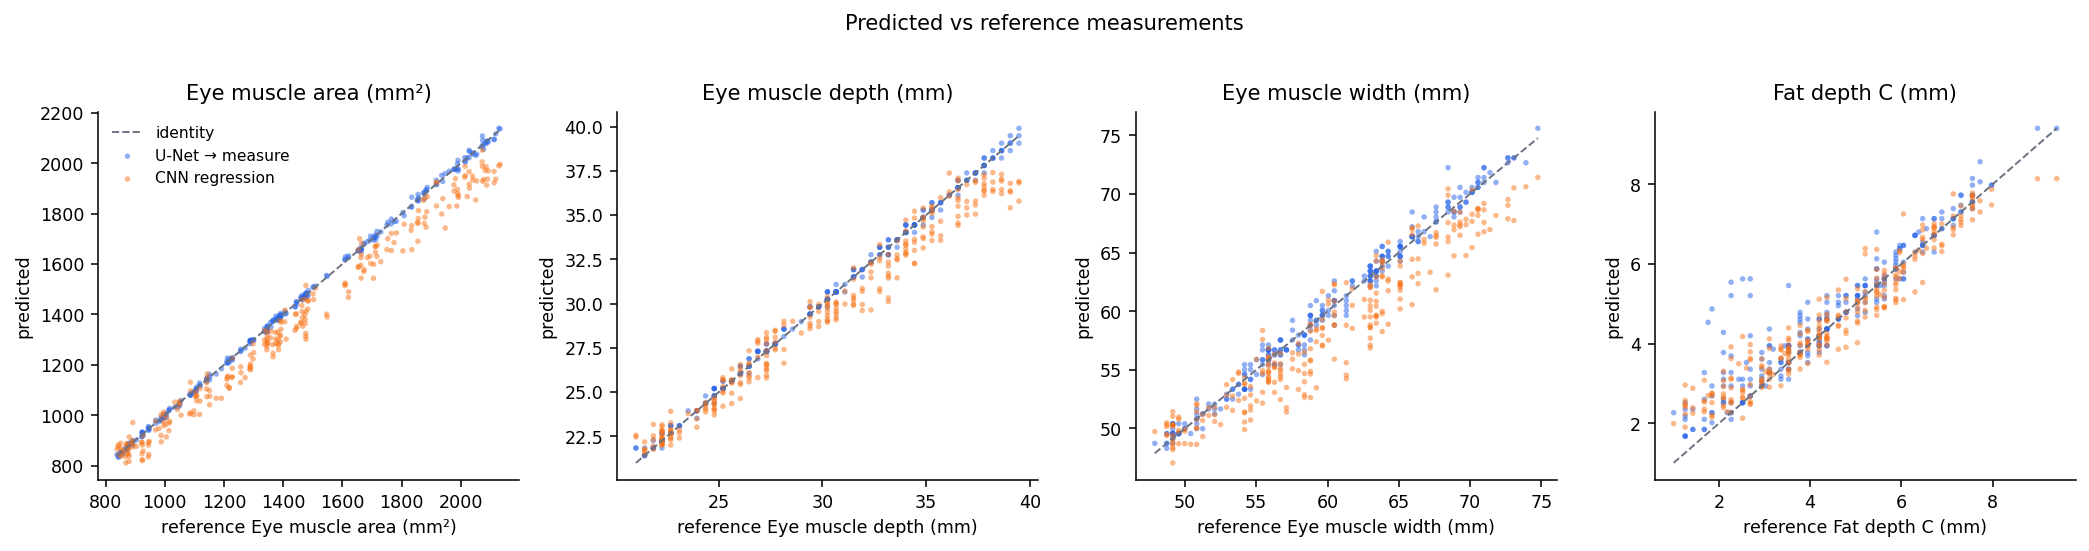

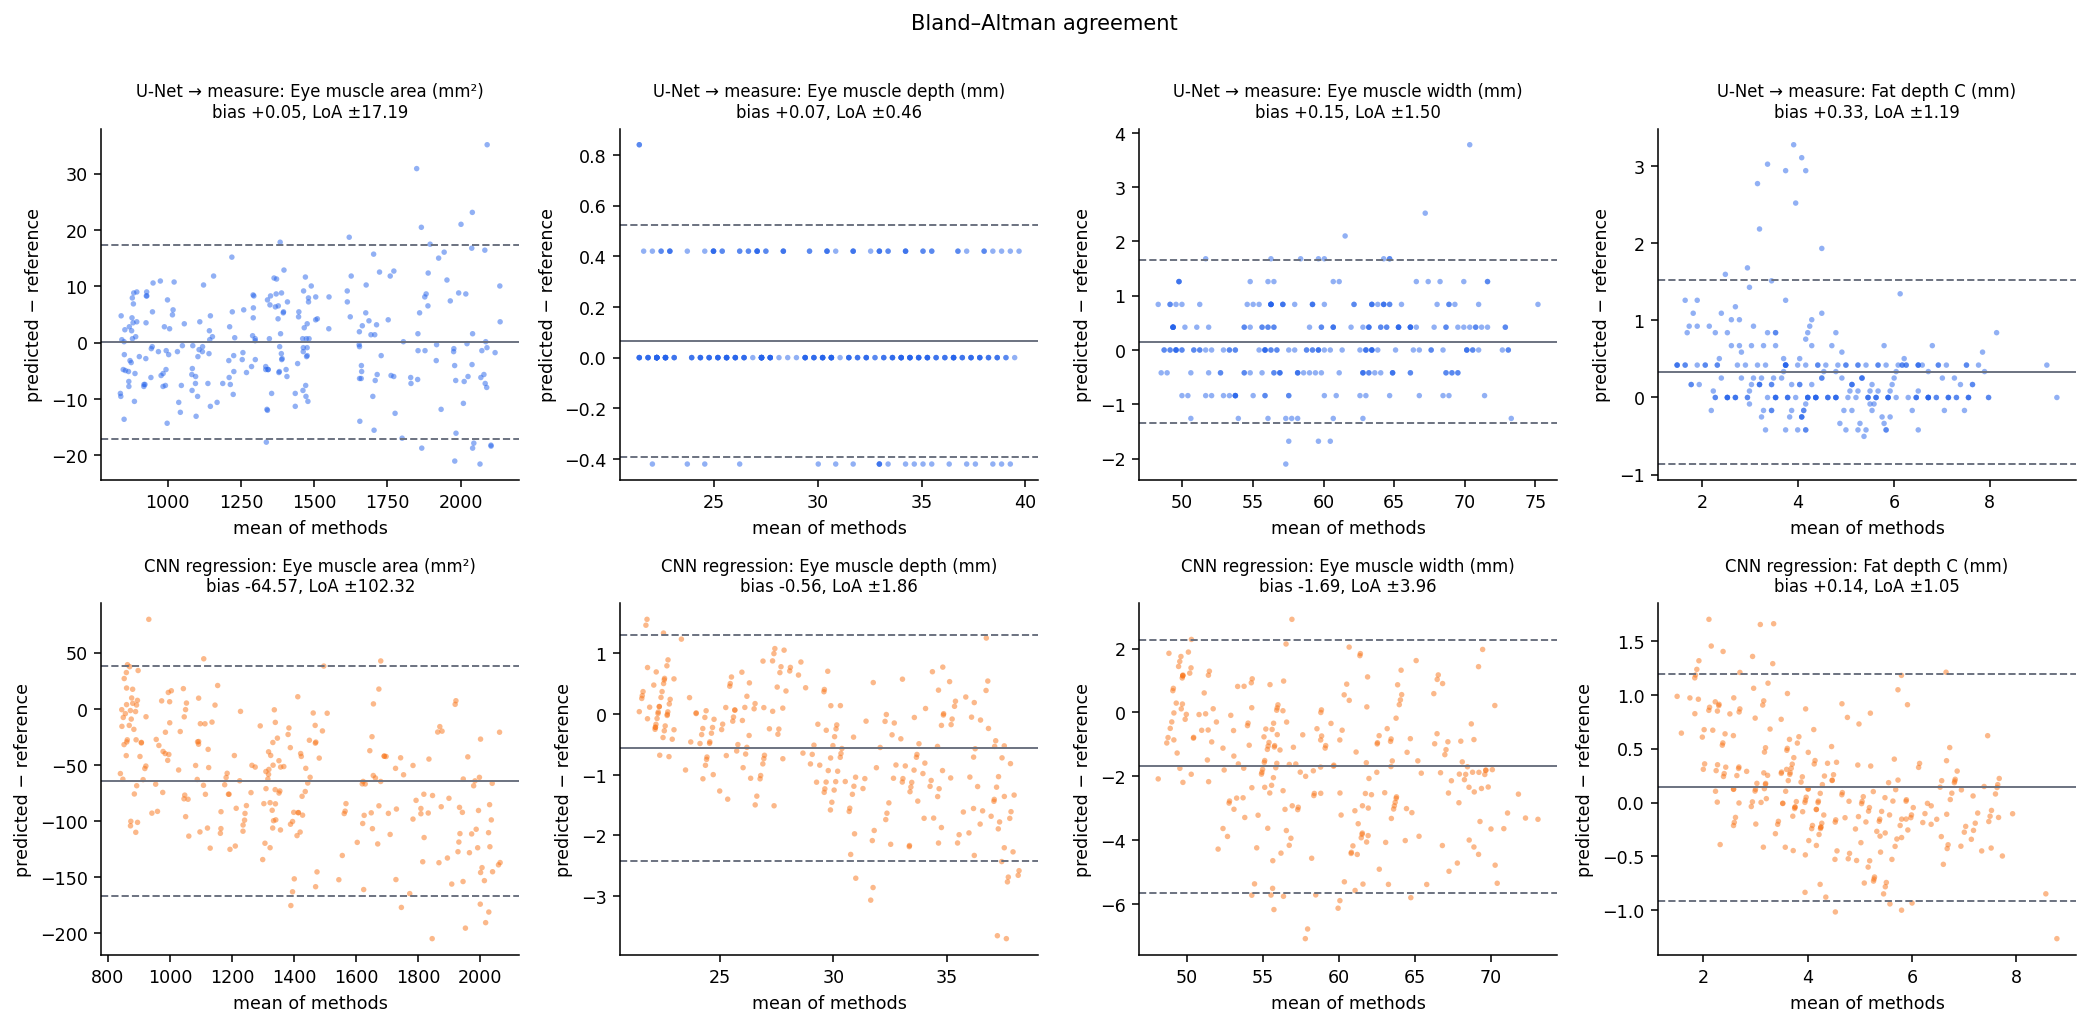

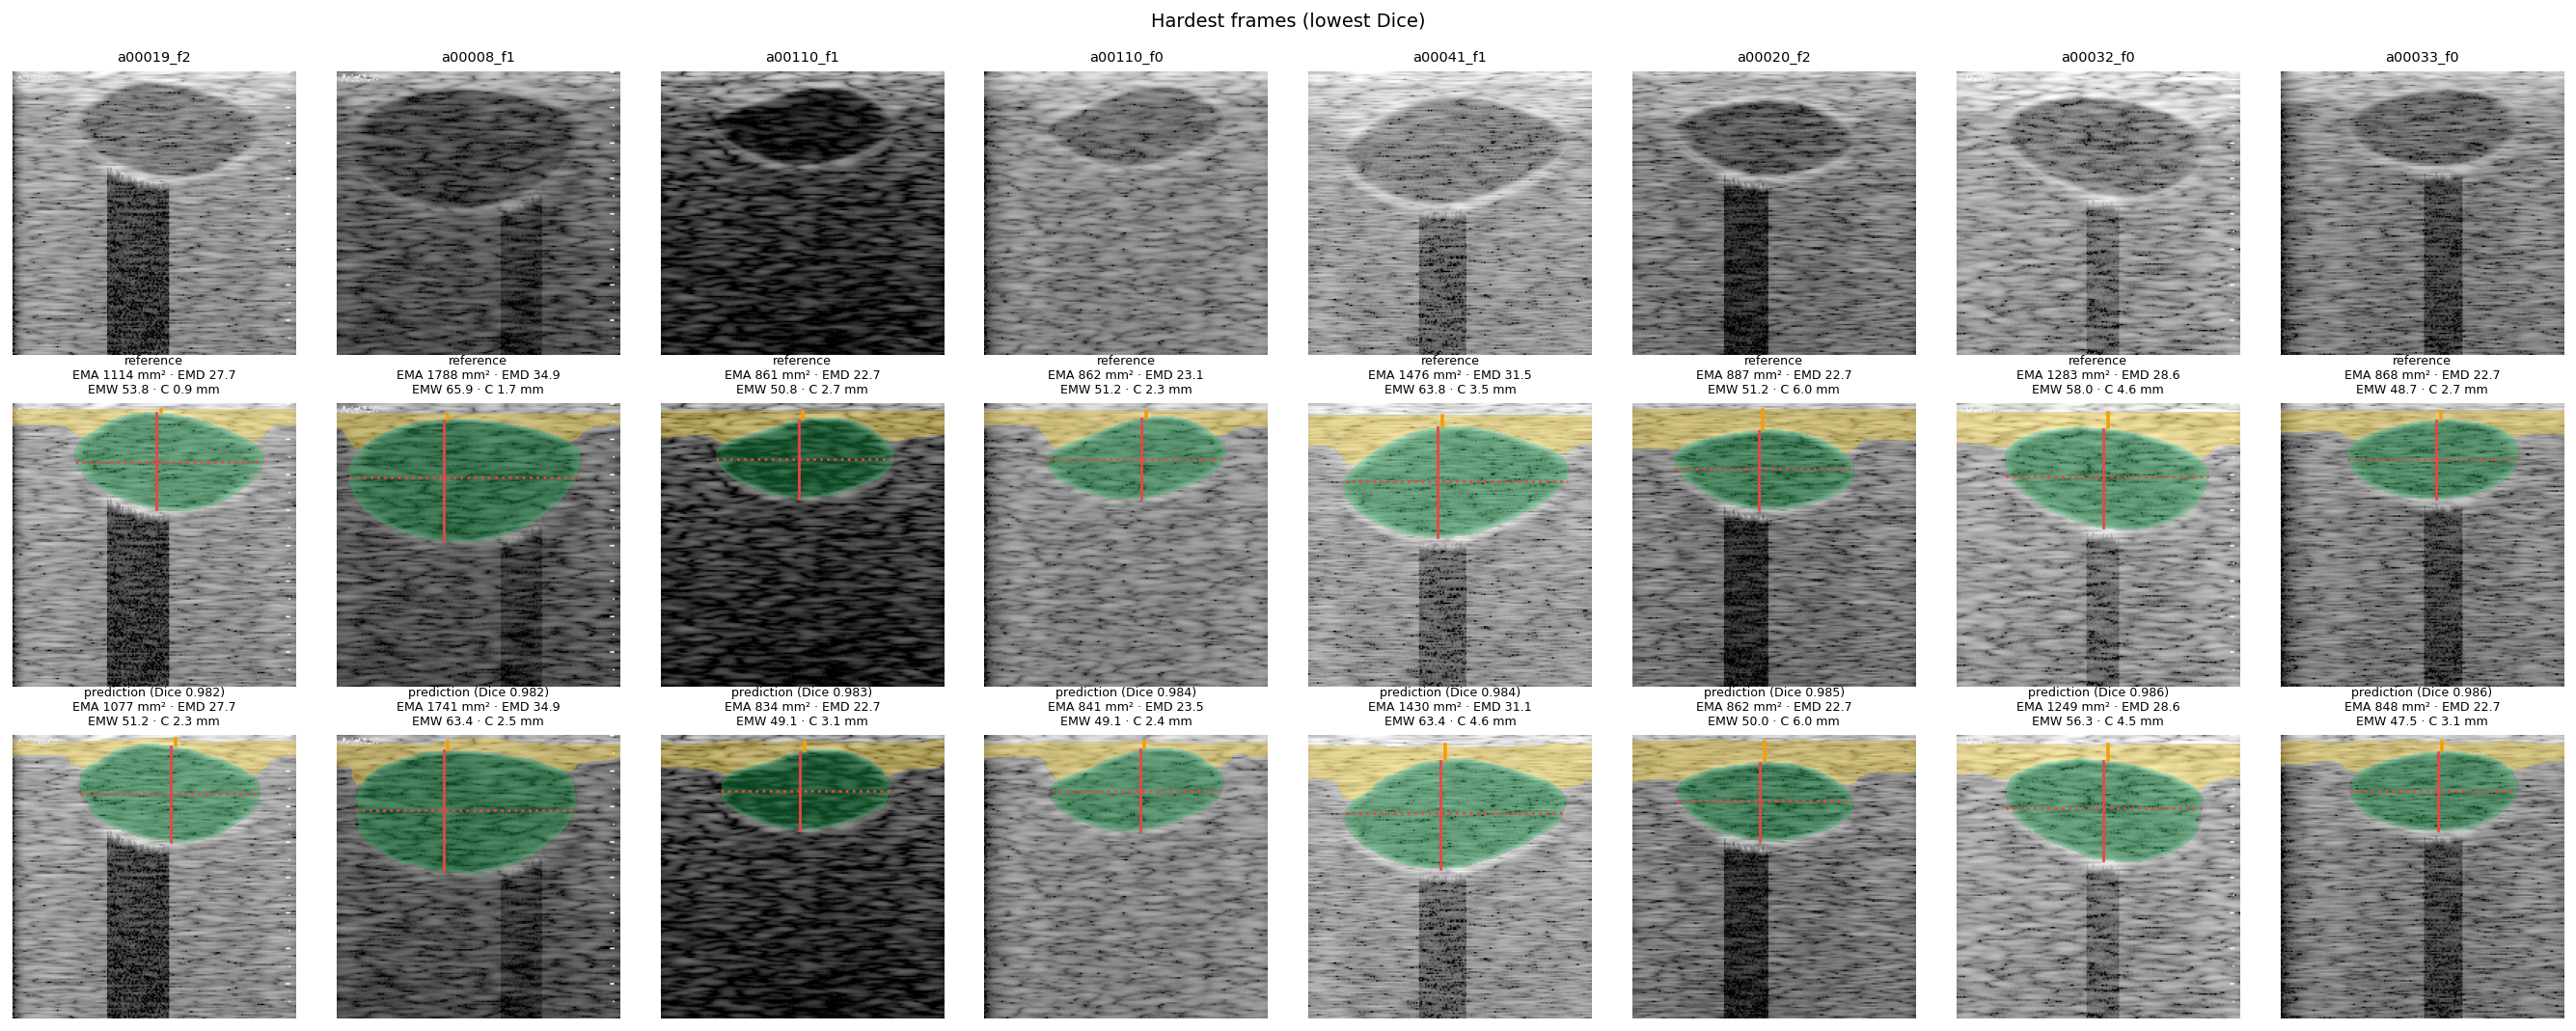

In [5]:
from IPython.display import Image, display
for f in ("../reports/test/figures/agreement.png", "../reports/test/figures/bland_altman.png",
          "../reports/shift/figures/qualitative_worst.png"):
    try: display(Image(f))
    except Exception as e: print(f, e)

## 4. Where would real data plug in?
`cvmeasure.data.annotation.import_labelme(...)` / `import_coco(...)` write the same on-disk layout as the synthetic generator, so `configs/default.yaml → data.root` is the only change needed to train on real annotated frames.